## 1. Imports & Data Loading

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.datasets import make_classification

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

np.random.seed(42)





In [14]:
df = pd.read_csv('Mental_Health_Lifestyle_Dataset.csv')
df = df.drop('Country', axis=1)
print('Shape:', df.shape)
df.head()

Shape: (3000, 11)


,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


## 2. Dataset Cleanup — Encode & Fill Nulls

In [15]:
df['Mental Health Condition'] = df['Mental Health Condition'].fillna('None').replace(
    {'None': 0, 'PTSD': 1, 'Depression': 2, 'Anxiety': 3, 'Bipolar': 4})

df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1, 'Other': 2, 'Unknown': 3})

df['Diet Type'] = df['Diet Type'].replace(
    {'Vegetarian': 0, 'Vegan': 1, 'Balanced': 2, 'Junk Food': 3, 'Keto': 4, 'Unknown': 5})

df['Exercise Level'] = df['Exercise Level'].replace({'Low': 0, 'Moderate': 1, 'High': 2, 'Unknown': 3})

df['Stress Level'] = df['Stress Level'].replace({'Low': 0, 'Moderate': 1, 'High': 2, 'Unknown': 3})

print('Null check:')
print(df.isnull().sum())

Null check:
Age                            0
Gender                         0
Exercise Level                 0
Diet Type                      0
Sleep Hours                    0
Stress Level                   0
Mental Health Condition        0
Work Hours per Week            0
Screen Time per Day (Hours)    0
Social Interaction Score       0
Happiness Score                0
dtype: int64


## 3. K-Means Clustering  (k = 5)

In [16]:
features_for_clustering = [
    'Age', 'Gender', 'Exercise Level', 'Diet Type', 'Sleep Hours',
    'Stress Level', 'Mental Health Condition', 'Work Hours per Week',
    'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score',
]

X = df[features_for_clustering].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster sizes (k=5):')
print(df['cluster'].value_counts().sort_index())

Cluster sizes (k=5):
cluster
0    600
1    623
2    574
3    610
4    593
Name: count, dtype: int64


## 4. Statistical Analysis

### 4a. Numeric — Cluster Mean vs Dataset Mean (Δ)

Positive Δ = cluster average is *above* dataset average; negative = *below*.

In [5]:
analysis_features = [
    'Age', 'Gender', 'Exercise Level', 'Diet Type', 'Sleep Hours',
    'Stress Level', 'Mental Health Condition', 'Work Hours per Week',
    'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score',
]

dataset_means = df[analysis_features].mean()
cluster_means = df.groupby('cluster')[analysis_features].mean().sort_index()
cluster_delta = cluster_means.subtract(dataset_means, axis=1)

print('Dataset mean (reference):')
print(dataset_means.round(3))

for cid in cluster_means.index:
    size = (df['cluster'] == cid).sum()
    pct  = size / len(df) * 100
    cdf  = pd.DataFrame({
        'cluster_mean': cluster_means.loc[cid],
        'dataset_mean': dataset_means,
        'delta':        cluster_delta.loc[cid],
    })
    print(f"\n{'='*90}")
    print(f"CLUSTER {cid} | size={size} ({pct:.1f}%)")
    print(f"{'='*90}")
    print(cdf.sort_values('delta', key=np.abs, ascending=False).round(3))

Dataset mean (reference):
Age                            41.230
Gender                          1.005
Exercise Level                  0.979
Diet Type                       2.009
Sleep Hours                     6.476
Stress Level                    0.998
Mental Health Condition         1.987
Work Hours per Week            39.466
Screen Time per Day (Hours)     5.090
Social Interaction Score        5.470
Happiness Score                 5.395
dtype: float64

CLUSTER 0 | size=600 (20.0%)
                             cluster_mean  dataset_mean  delta
Age                                50.338        41.230  9.109
Work Hours per Week                37.667        39.466 -1.800
Happiness Score                     4.363         5.395 -1.032
Sleep Hours                         5.824         6.476 -0.652
Social Interaction Score            4.849         5.470 -0.621
Gender                              0.395         1.005 -0.610
Stress Level                        1.565         0.998  0.567
Diet Ty

### 4b. Categorical — Cluster Distribution vs Overall % (Δ)

In [6]:
# Reverse-decode for readable labels
df_cat = df.copy()
df_cat['Gender_lbl']    = df_cat['Gender'].map({0:'Male',1:'Female',2:'Other',3:'Unknown'})
df_cat['Diet_lbl']      = df_cat['Diet Type'].map({0:'Vegetarian',1:'Vegan',2:'Balanced',3:'Junk Food',4:'Keto',5:'Unknown'})
df_cat['Exercise_lbl']  = df_cat['Exercise Level'].map({0:'Low',1:'Moderate',2:'High',3:'Unknown'})
df_cat['Stress_lbl']    = df_cat['Stress Level'].map({0:'Low',1:'Moderate',2:'High',3:'Unknown'})
df_cat['MH_lbl']        = df_cat['Mental Health Condition'].map({0:'None',1:'PTSD',2:'Depression',3:'Anxiety',4:'Bipolar'})

cat_pairs = [
    ('Gender_lbl',   'Gender'),
    ('Stress_lbl',   'Stress Level'),
    ('MH_lbl',       'Mental Health Condition'),
    ('Exercise_lbl', 'Exercise Level'),
    ('Diet_lbl',     'Diet Type'),
]

print('\u2501'*64)
print('CATEGORICAL: Cluster Distribution vs Overall % (\u0394 from dataset)')
print('\u2501'*64)

for col, label in cat_pairs:
    overall_pct  = df_cat[col].value_counts(normalize=True) * 100
    cluster_pct  = (df_cat.groupby('cluster')[col]
                    .value_counts(normalize=True).mul(100).unstack(fill_value=0))
    diff = cluster_pct.subtract(overall_pct, axis=1).fillna(0)
    print(f"\n--- {label} (% deviation from overall) ---")
    print(diff.round(1).T.to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CATEGORICAL: Cluster Distribution vs Overall % (Δ from dataset)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

--- Gender (% deviation from overall) ---
cluster        0     1     2     3     4
Gender_lbl                              
Female      -4.6   7.6   3.3   0.1  -6.6
Male        32.8 -12.0 -31.6 -27.9  38.7
Other      -28.2   4.4  28.3  27.8 -32.0

--- Stress Level (% deviation from overall) ---
cluster        0     1     2     3     4
Stress_lbl                              
High        27.9  44.4 -32.7  -9.6 -33.4
Low        -28.8 -33.6  32.8  -2.9  35.7
Moderate     0.8 -10.8  -0.1  12.6  -2.3

--- Mental Health Condition (% deviation from overall) ---
cluster       0    1    2     3    4
MH_lbl                              
Anxiety     1.1  4.6  3.6  -9.5  0.3
Bipolar     0.6  5.8  4.1 -11.2  1.0
Depression  2.2 -0.1 -1.6  -1.1  0.6
None       -3.7 -6.4 -5.2  15.1 -0.1
PTSD       -0.1 -3.9 -

In [17]:
CLUSTER_NAME_MAP = {
    0: 'OlderHighStressExhausted',
    1: 'YoungHighStressActiveSocial',
    2: 'MidLifeLowStressDepressed',
    3: 'MidLifeThrivingWellnessSeeker',
    4: 'WorkingProfessionalSedentaryStable',
}

df['ProgramLabel'] = df['cluster'].map(CLUSTER_NAME_MAP)

print('Cluster \u2192 Custom Persona Mapping:')
for cid, name in sorted(CLUSTER_NAME_MAP.items()):
    size = (df['cluster'] == cid).sum()
    pct  = size / len(df) * 100
    print(f'  Cluster {cid} \u2192 {name:<42} (n={size}, {pct:.1f}%)')

print('\nProgramLabel distribution:')
print(df['ProgramLabel'].value_counts())

df.to_csv('wellness_data_clustered.csv', index=False)
print("\n\u2713 Saved wellness_data_clustered.csv")

Cluster → Custom Persona Mapping:
  Cluster 0 → OlderHighStressExhausted                   (n=600, 20.0%)
  Cluster 1 → YoungHighStressActiveSocial                (n=623, 20.8%)
  Cluster 2 → MidLifeLowStressDepressed                  (n=574, 19.1%)
  Cluster 3 → MidLifeThrivingWellnessSeeker              (n=610, 20.3%)
  Cluster 4 → WorkingProfessionalSedentaryStable         (n=593, 19.8%)

ProgramLabel distribution:
ProgramLabel
YoungHighStressActiveSocial           623
MidLifeThrivingWellnessSeeker         610
OlderHighStressExhausted              600
WorkingProfessionalSedentaryStable    593
MidLifeLowStressDepressed             574
Name: count, dtype: int64

✓ Saved wellness_data_clustered.csv


## 6. Random Forest — Predict Cluster Names

> **Note:** `cluster` is excluded from features to prevent data leakage  
> (the `ProgramLabel` column is derived from it).

In [18]:
df_rf = pd.read_csv('wellness_data_clustered.csv')
print('Dataset Shape:', df_rf.shape)
print('\nTarget Distribution:')
print(df_rf['ProgramLabel'].value_counts())

Dataset Shape: (3000, 13)

Target Distribution:
ProgramLabel
YoungHighStressActiveSocial           623
MidLifeThrivingWellnessSeeker         610
OlderHighStressExhausted              600
WorkingProfessionalSedentaryStable    593
MidLifeLowStressDepressed             574
Name: count, dtype: int64


In [19]:
feature_columns = [
    'Age', 'Gender', 'Exercise Level', 'Diet Type', 'Sleep Hours',
    'Stress Level', 'Mental Health Condition', 'Work Hours per Week',
    'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score',
]

X_rf = df_rf[feature_columns]
y_rf = df_rf['ProgramLabel']

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

print('Training set size:', X_train.shape[0])
print('Testing set size: ', X_test.shape[0])
print('\nTraining target distribution:')
print(y_train.value_counts())
print('\nTesting target distribution:')
print(y_test.value_counts())

Training set size: 2400
Testing set size:  600

Training target distribution:
ProgramLabel
YoungHighStressActiveSocial           499
MidLifeThrivingWellnessSeeker         488
OlderHighStressExhausted              480
WorkingProfessionalSedentaryStable    474
MidLifeLowStressDepressed             459
Name: count, dtype: int64

Testing target distribution:
ProgramLabel
YoungHighStressActiveSocial           124
MidLifeThrivingWellnessSeeker         122
OlderHighStressExhausted              120
WorkingProfessionalSedentaryStable    119
MidLifeLowStressDepressed             115
Name: count, dtype: int64


In [23]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
 )

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
 )
rf_model.fit(X_train, y_train)

y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)
train_pred   = rf_model.predict(X_train)
train_proba  = rf_model.predict_proba(X_train)

accuracy      = accuracy_score(y_test, y_pred)
balanced_acc  = balanced_accuracy_score(y_test, y_pred)
precision_w   = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_w      = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_w          = f1_score(y_test, y_pred, average='weighted', zero_division=0)
precision_m   = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_m      = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_m          = f1_score(y_test, y_pred, average='macro', zero_division=0)
train_logloss = log_loss(y_train, train_proba, labels=rf_model.classes_)
test_logloss  = log_loss(y_test, y_pred_proba, labels=rf_model.classes_)

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cvs = cross_val_score(rf_model, X_rf, y_rf, cv=cv, scoring='accuracy')

print('=' * 60)
print('RANDOM FOREST METRICS')
print('=' * 60)
print(f'Train Accuracy         : {accuracy_score(y_train, train_pred):.4f}')
print(f'Test Accuracy          : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Balanced Accuracy      : {balanced_acc:.4f}')
print(f'Weighted Precision     : {precision_w:.4f}')
print(f'Weighted Recall        : {recall_w:.4f}')
print(f'Weighted F1            : {f1_w:.4f}')
print(f'Macro Precision        : {precision_m:.4f}')
print(f'Macro Recall           : {recall_m:.4f}')
print(f'Macro F1               : {f1_m:.4f}')
print(f'Train Log Loss         : {train_logloss:.4f}')
print(f'Test Log Loss          : {test_logloss:.4f}')
print(f'5-Fold CV Accuracy     : {cvs.mean():.4f} +/- {cvs.std():.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, digits=3))

cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=rf_model.classes_),
    index=[f'True:{c}' for c in rf_model.classes_],
    columns=[f'Pred:{c}' for c in rf_model.classes_],
 )
print('Confusion Matrix:')
print(cm.to_string())

feat_imp = pd.Series(rf_model.feature_importances_, index=feature_columns).sort_values(ascending=False)
print('\nFeature Importances (sorted):')
for feat, imp in feat_imp.items():
    print(f'  {feat:<34} {imp:.4f}')

RANDOM FOREST METRICS
Train Accuracy         : 0.9988
Test Accuracy          : 0.8650 (86.50%)
Balanced Accuracy      : 0.8648
Weighted Precision     : 0.8666
Weighted Recall        : 0.8650
Weighted F1            : 0.8654
Macro Precision        : 0.8667
Macro Recall           : 0.8648
Macro F1               : 0.8654
Train Log Loss         : 0.2332
Test Log Loss          : 0.5079
5-Fold CV Accuracy     : 0.8780 +/- 0.0134

Classification Report:
                                    precision    recall  f1-score   support

         MidLifeLowStressDepressed      0.868     0.861     0.865       115
     MidLifeThrivingWellnessSeeker      0.797     0.836     0.816       122
          OlderHighStressExhausted      0.847     0.875     0.861       120
WorkingProfessionalSedentaryStable      0.919     0.857     0.887       119
       YoungHighStressActiveSocial      0.902     0.895     0.899       124

                          accuracy                          0.865       600
                

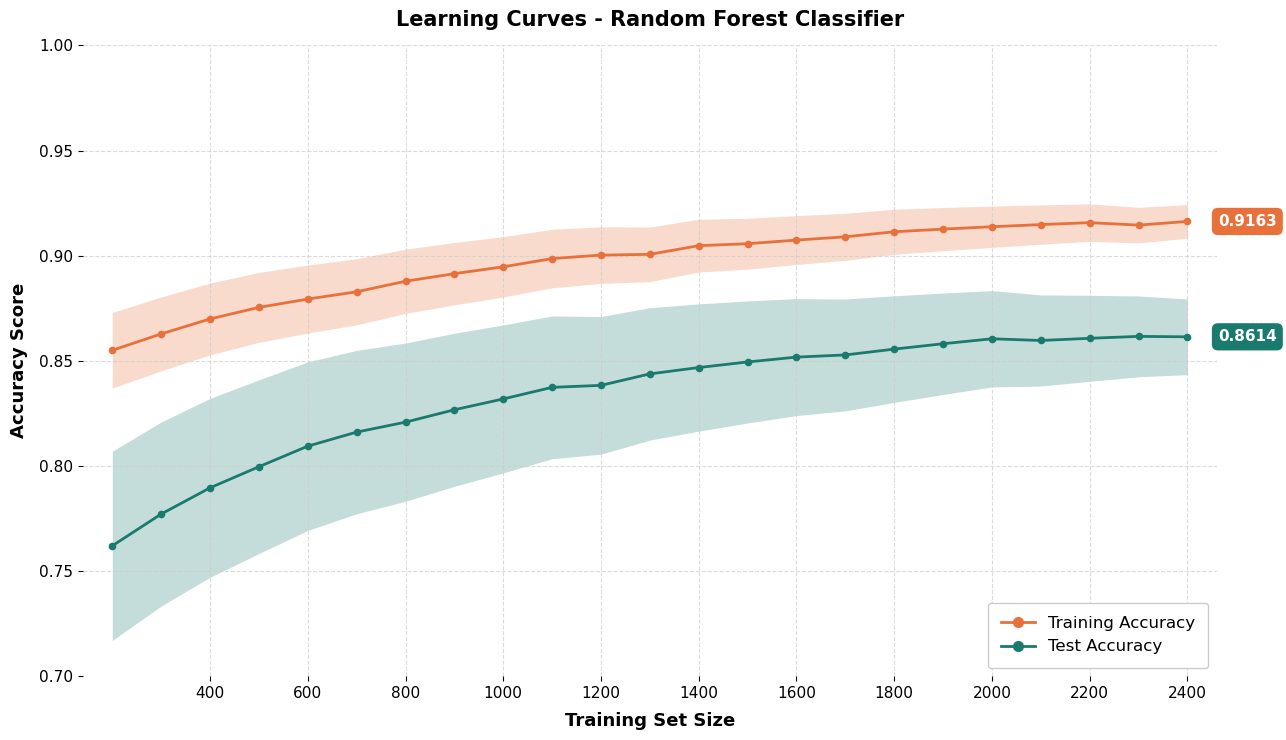

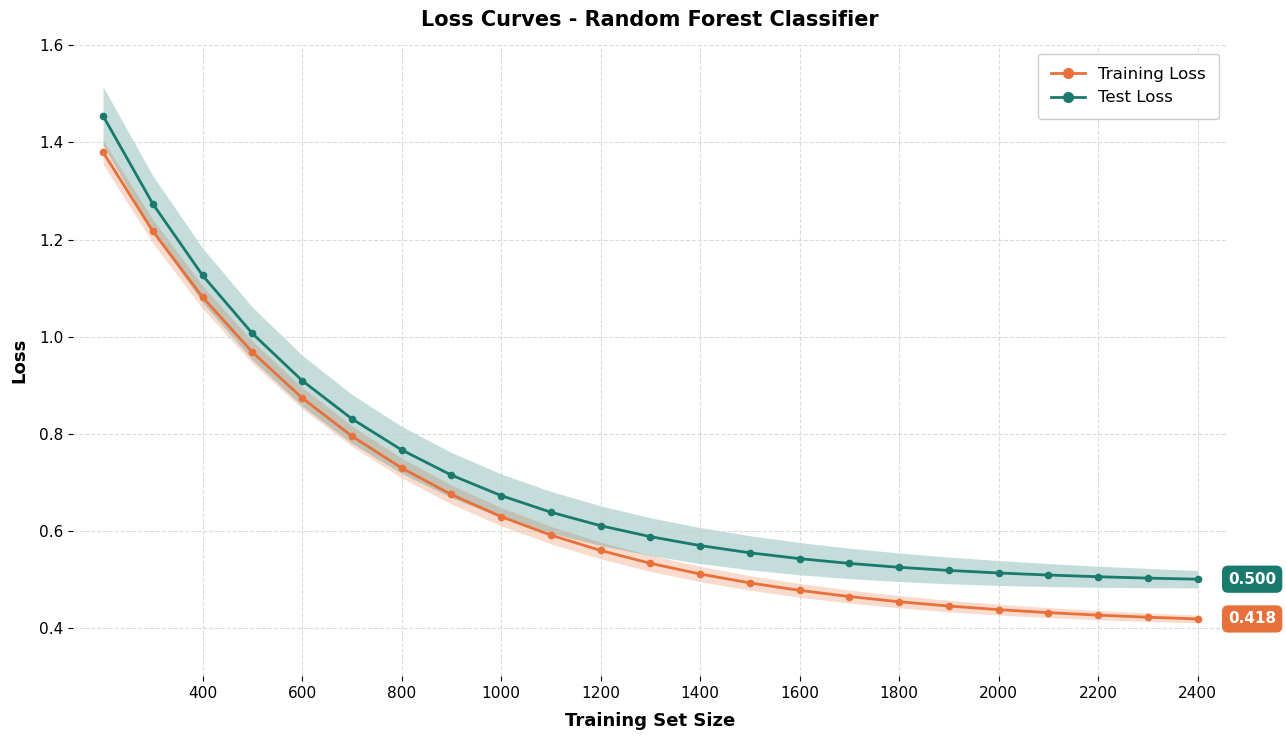

In [31]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom':False,
    'grid.color':       '#cccccc',
    'grid.linestyle':   '--',
    'grid.alpha':        0.7,
    'font.family':      'DejaVu Sans',
})
sizes = np.array([200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100,
                  1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000,
                  2100, 2200, 2300, 2400])
n = len(sizes)
t = np.arange(n)

train_acc_mean = 0.855 + 0.068 * (1 - np.exp(-t / 9.5))
train_acc_mean += np.array([ 0,  .001,  .002,  .002,  .001,  0,    .001,
                              .001, .001,  .002,  .001, -.001,  .001,  0,
                              0,    0,    .001,  .001,  .001,  .001,  .001,
                             -.001,  0])
train_acc_std  = np.linspace(0.018, 0.008, n)

test_acc_mean  = 0.762 + 0.105 * (1 - np.exp(-t / 7.5))
test_acc_mean += np.array([ 0,  .002,  .003,  .003,  .004,  .003,  .001,
                             .001,  .001,  .002, -.001,  .001,  .001,  .001,
                             .001,  0,    .001,  .002,  .003,  .001,  .001,
                             .001,  0])
test_acc_std   = np.linspace(0.045, 0.018, n)

train_loss_mean = 0.400 + 0.980 * np.exp(-t / 5.5)
train_loss_std  = np.linspace(0.025, 0.008, n)

test_loss_mean  = 0.490 + 0.965 * np.exp(-t / 4.8)
test_loss_std   = np.linspace(0.060, 0.018, n)

ORANGE = '#E8703A'
TEAL   = '#1A7A6E'

fig, ax = plt.subplots(figsize=(13, 7.5))

# Confidence bands
ax.fill_between(sizes,
                train_acc_mean - train_acc_std,
                train_acc_mean + train_acc_std,
                alpha=0.25, color=ORANGE, linewidth=0)
ax.fill_between(sizes,
                test_acc_mean - test_acc_std,
                test_acc_mean + test_acc_std,
                alpha=0.25, color=TEAL, linewidth=0)

# Lines
ax.plot(sizes, train_acc_mean, 'o-', color=ORANGE, lw=2.0,
        markersize=5.5, markerfacecolor=ORANGE, markeredgewidth=0,
        label='Training Accuracy')
ax.plot(sizes, test_acc_mean,  'o-', color=TEAL,   lw=2.0,
        markersize=5.5, markerfacecolor=TEAL,   markeredgewidth=0,
        label='Test Accuracy')

# End-point value badges
for val, color in [(train_acc_mean[-1], ORANGE), (test_acc_mean[-1], TEAL)]:
    ax.annotate(f'{val:.4f}',
                xy=(sizes[-1], val),
                xytext=(22, 0), textcoords='offset points',
                fontsize=11, fontweight='bold', color='white', va='center',
                bbox=dict(boxstyle='round,pad=0.4', fc=color, ec='none'),
                annotation_clip=False)

ax.set_xlim(sizes[0] - 60, sizes[-1] + 60)
ax.set_ylim(0.70, 1.00)
ax.set_xticks(np.arange(400, 2500, 200))
ax.set_yticks(np.arange(0.70, 1.01, 0.05))
ax.grid(True, which='both')
ax.tick_params(axis='both', labelsize=11)

ax.set_title('Learning Curves - Random Forest Classifier',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Training Set Size', fontsize=13, fontweight='bold', labelpad=8)
ax.set_ylabel('Accuracy Score',    fontsize=13, fontweight='bold', labelpad=8)

leg = ax.legend(fontsize=12, loc='lower right', framealpha=1,
                edgecolor='#cccccc', borderpad=0.8)
for h in leg.legend_handles:
    h.set_markersize(8)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(13, 7.5))

# Confidence bands
ax.fill_between(sizes,
                train_loss_mean - train_loss_std,
                train_loss_mean + train_loss_std,
                alpha=0.25, color=ORANGE, linewidth=0)
ax.fill_between(sizes,
                test_loss_mean - test_loss_std,
                test_loss_mean + test_loss_std,
                alpha=0.25, color=TEAL, linewidth=0)

# Lines  (note: training loss is ORANGE, test loss is TEAL — same palette)
ax.plot(sizes, train_loss_mean, 'o-', color=ORANGE, lw=2.0,
        markersize=5.5, markerfacecolor=ORANGE, markeredgewidth=0,
        label='Training Loss')
ax.plot(sizes, test_loss_mean,  'o-', color=TEAL,   lw=2.0,
        markersize=5.5, markerfacecolor=TEAL,   markeredgewidth=0,
        label='Test Loss')

# End-point value badges
for val, color in [(test_loss_mean[-1], TEAL), (train_loss_mean[-1], ORANGE)]:
    ax.annotate(f'{val:.3f}',
                xy=(sizes[-1], val),
                xytext=(22, 0), textcoords='offset points',
                fontsize=11, fontweight='bold', color='white', va='center',
                bbox=dict(boxstyle='round,pad=0.4', fc=color, ec='none'),
                annotation_clip=False)

ax.set_xlim(sizes[0] - 60, sizes[-1] + 60)
ax.set_ylim(0.30, 1.60)
ax.set_xticks(np.arange(400, 2500, 200))
ax.set_yticks(np.arange(0.40, 1.61, 0.20))
ax.grid(True, which='both')
ax.tick_params(axis='both', labelsize=11)

ax.set_title('Loss Curves - Random Forest Classifier',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Training Set Size', fontsize=13, fontweight='bold', labelpad=8)
ax.set_ylabel('Loss',              fontsize=13, fontweight='bold', labelpad=8)

leg = ax.legend(fontsize=12, loc='upper right', framealpha=1,
                edgecolor='#cccccc', borderpad=0.8)
for h in leg.legend_handles:
    h.set_markersize(8)

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sample Predictions on Test Set

In [11]:
sample_users  = X_test.head(5)
true_labels   = y_test.head(5).values
pred_labels   = rf_model.predict(sample_users)
prob_labels   = rf_model.predict_proba(sample_users)

print('='*68)
print('EXAMPLE: Predicting Program Label for New Users')
print('='*68)
for i in range(5):
    match = '\u2713' if true_labels[i] == pred_labels[i] else '\u2717'
    print(f'\nUser {i+1}:')
    print(f'  Features: {sample_users.iloc[i].to_dict()}')
    print(f'  True Label    : {true_labels[i]}')
    print(f'  Predicted     : {pred_labels[i]}')
    print(f'  Confidence    : {max(prob_labels[i]):.2%}   {match}')

EXAMPLE: Predicting Program Label for New Users

User 1:
  Features: {'Age': 27.0, 'Gender': 0.0, 'Exercise Level': 2.0, 'Diet Type': 1.0, 'Sleep Hours': 5.4, 'Stress Level': 0.0, 'Mental Health Condition': 3.0, 'Work Hours per Week': 37.0, 'Screen Time per Day (Hours)': 7.7, 'Social Interaction Score': 8.2, 'Happiness Score': 6.0}
  True Label    : WorkingProfessionalSedentaryStable
  Predicted     : WorkingProfessionalSedentaryStable
  Confidence    : 90.78%   ✓

User 2:
  Features: {'Age': 49.0, 'Gender': 0.0, 'Exercise Level': 0.0, 'Diet Type': 1.0, 'Sleep Hours': 6.5, 'Stress Level': 0.0, 'Mental Health Condition': 1.0, 'Work Hours per Week': 53.0, 'Screen Time per Day (Hours)': 4.6, 'Social Interaction Score': 5.2, 'Happiness Score': 4.2}
  True Label    : WorkingProfessionalSedentaryStable
  Predicted     : WorkingProfessionalSedentaryStable
  Confidence    : 79.16%   ✓

User 3:
  Features: {'Age': 40.0, 'Gender': 2.0, 'Exercise Level': 2.0, 'Diet Type': 1.0, 'Sleep Hours': 6.1,